<a href="https://colab.research.google.com/github/minato1204love-TTP/Khang_INFO4670_Fall2026/blob/main/Week_5_Assignment_3_INFO_4670.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [3]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [4]:
# Install packages if needed
!pip install mlxtend networkx -q

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.frequent_patterns import fpgrowth, association_rules

# Load dataset
df = pd.read_csv("bread_basket.csv")

# Preview the data
print("Shape:", df.shape)
print("Unique transactions:", df["transaction"].nunique())
df.head()

Shape: (20507, 6)
Unique transactions: 9465


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [5]:
# List variables and their data types
print(df.dtypes)

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [6]:
# Statistical overview
df.describe(include="all")

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

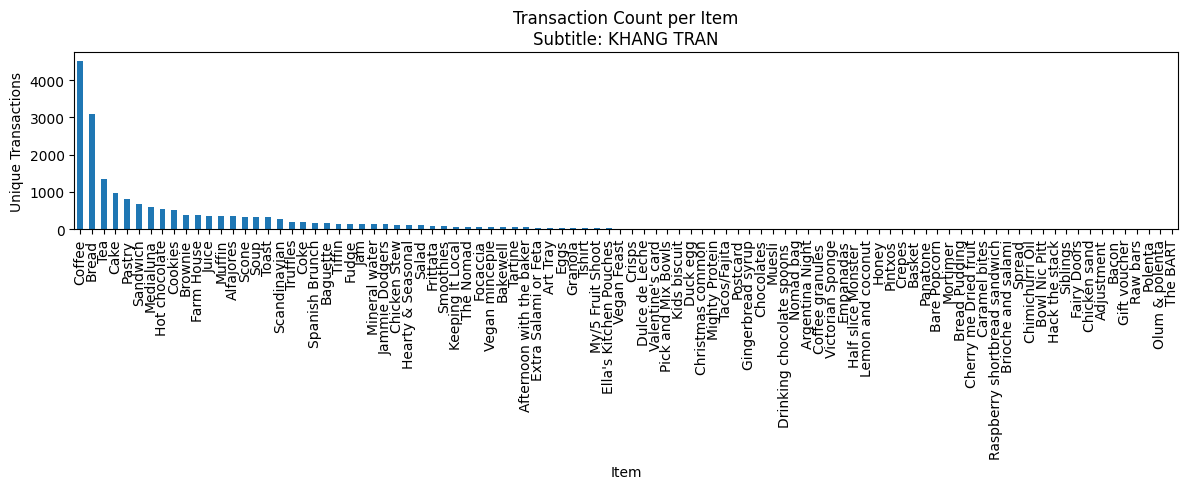

In [13]:
# c) Bar plot of transaction counts per item

subtitle = "KHANG TRAN"

item_counts = (df.groupby("item")["transaction"]
                 .nunique()
                 .sort_values(ascending=False))

ax = item_counts.plot(kind="bar", figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item")
plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [8]:
# d) Report transaction counts for selected items

selected_items = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

selected_counts = (
    df[df["item"].isin(selected_items)]
    .groupby("item")["transaction"]
    .nunique()
    .reindex(selected_items)
)

selected_counts

,transaction
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [9]:
# Create transaction × item one-hot table

basket = (
    df.assign(present=True)
      .drop_duplicates(["transaction", "item"])
      .pivot(index="transaction", columns="item", values="present")
      .fillna(False)
      .astype(bool)
)

print("Basket shape:", basket.shape)
basket.head()

Basket shape: (9465, 94)


item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Frequent itemsets using FP-Growth

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets

,support,itemsets
0,0.478394,(Coffee)
1,0.327205,(Bread)
2,0.142631,(Tea)
3,0.103856,(Cake)
4,0.090016,"(Coffee, Bread)"
5,0.086107,(Pastry)
6,0.071844,(Sandwich)
7,0.061807,(Medialuna)
8,0.058320,(Hot chocolate)
9,0.054728,"(Cake, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [11]:
# Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

rules = rules.sort_values(
    by="confidence",
    ascending=False
).reset_index(drop=True)

rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
1,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
2,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
3,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
4,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
5,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
6,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
7,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
8,(Tea),(Coffee),0.142631,0.478394,0.049868,0.349630,0.730840,1.0,-0.018366,0.802014,-0.300482,0.087310,-0.246862,0.226935
9,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884


In [12]:
# Create report table

report = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

report["antecedents"] = report["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

report["consequents"] = report["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

report.head(20)

,antecedents,consequents,support,confidence,lift
0,Toast,Coffee,0.023666,0.704403,1.472431
1,Medialuna,Coffee,0.035182,0.569231,1.189878
2,Pastry,Coffee,0.047544,0.552147,1.154168
3,Juice,Coffee,0.020602,0.534247,1.116750
4,Sandwich,Coffee,0.038246,0.532353,1.112792
5,Cake,Coffee,0.054728,0.526958,1.101515
6,Cookies,Coffee,0.028209,0.518447,1.083723
7,Hot chocolate,Coffee,0.029583,0.507246,1.060311
8,Tea,Coffee,0.049868,0.349630,0.730840
9,Pastry,Bread,0.029160,0.338650,1.034977


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* The rule {Coffee, Cake} ⇒ {Bread} has a support of approximately 0.010, meaning that about 1.0% of all transactions contain Coffee, Cake, and Bread together.

The confidence is approximately 0.183, meaning that among transactions containing both Coffee and Cake, about 18.3% also contain Bread.

The lift is approximately 0.56. Because the lift is less than 1, Coffee and Cake are not positively associated with Bread. In practical terms, customers who purchase Coffee and Cake together are less likely to also purchase Bread than would be expected based on the overall popularity of Bread.

>